# 01 — A simple Caligo walkthrough with GJ 1214 b

The setup notebook checked that PICASO, Photochem, VIRGA, and Caligo can all work in the same environment. This notebook starts using **Caligo itself**.

The goal is not to turn every possible setting on at once. Each section introduces one part of the model, shows the main options, and then uses one choice for the GJ 1214 b example.

The basic Caligo flow is:

```text
PICASO atmosphere
      ↓
Photochem chemistry
      ↓
choose a haze source
      ↓
particle grid
      ↓
coagulation + transport + settling + sinks
      ↓
steady-state haze distribution
      ↓
optional optical properties + PICASO spectrum
```

The main settings can be changed without rewriting the rest of the notebook.

## 1. Imports and local paths

All imports are kept here at the beginning.

This notebook assumes the environment and reference data from Notebook 00 are already set up.

In [ ]:
from pathlib import Path
import os
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

from astropy import constants as const
from astropy import units as u

import picaso.photochem as picasochem

import caligo.justdoit as cdi
from caligo import background as cb
from caligo import diagnostics as diag
from caligo import optics as copt


# Change this path if Caligo lives somewhere else.
PROJECT_ROOT = Path("/Users/svc553/Documents/Caligo")
os.chdir(PROJECT_ROOT)

# The MUSCLES file made in Notebook 00.
STELLAR_FLUX_FILE = PROJECT_ROOT / "data/stellar_flux/GJ1214_test.txt"

print("Caligo folder:", PROJECT_ROOT)
print("Stellar spectrum:", STELLAR_FLUX_FILE)

Caligo folder: /Users/svc553/Documents/Caligo
Stellar spectrum: /Users/svc553/Documents/Caligo/data/stellar_flux/GJ1214_test.txt


## 2. The options that matter most

These are the choices that are most useful for comparison runs.

| Part of the model | Main options |
|---|---|
| Haze source shape | `photochem` or `gaussian` |
| Source strength | fixed haze flux or scaled Photochem flux |
| Fresh particle sizes | `single_bin`, `lognormal`, or `custom_weights` |
| Particle structure | compact particles or aggregates |
| Coagulation | on/off, Brownian collisions, differential settling, charge suppression |
| Bottom boundary | `deposition_velocity`, `open_flux`, or `zero_flux` |
| Thermal destruction | on or off |
| Optical treatment | `compact_mie` or `aggregate_effective_mie` |

The example below uses one baseline set of choices, but each option is kept in its own small section.

# Part I — Build the atmospheric background

## 3. GJ 1214 b inputs

The background atmosphere comes from PICASO and Photochem.

These are the working values used for this example.

In [ ]:
r_planet = (0.2438 * const.R_jup).to(u.cm).value
m_planet = (0.0265 * const.M_jup).to(u.g).value

planet_Teq = 567.0
planet_tint = 30.0
semi_major_AU = 0.01505

stellar_radius_Rsun = 0.2162
stellar_Teff = 3101.0
stellar_metal = 0.24
stellar_logg = 5.0286

CLIMATE_NLEVEL = 141
CLIMATE_P_BOTTOM_LOG10 = 3.0
CLIMATE_P_TOP_LOG10 = -7.0

print("GJ 1214 b")
print("Teq:", planet_Teq, "K")
print("Orbit:", semi_major_AU, "AU")

GJ 1214 b
Teq: 567.0 K
Orbit: 0.01505 AU


## 4. Make the Photochem input files

Photochem needs a reaction network, thermodynamic data, and a stellar spectrum.

The reaction and thermo files can be generated directly through PICASO. The stellar spectrum is the MUSCLES file made in Notebook 00.

In [ ]:
picasochem.generate_photochem_rx_and_thermo_files()

MECHANISM_FILE = PROJECT_ROOT / "photochem_rxns.yaml"
THERMO_FILE = PROJECT_ROOT / "photochem_thermo.yaml"

for file in [MECHANISM_FILE, THERMO_FILE, STELLAR_FLUX_FILE]:
    print(file.name, ":", file.exists())

photochem_rxns.yaml : True
photochem_thermo.yaml : True
GJ1214_test.txt : True


## 5. Start the Caligo case

Caligo uses a PICASO-style interface. The opacity connection and atmospheric inputs are attached to one `case` object and reused through the rest of the notebook.

In [ ]:
gases = [
    "H2O", "NH3", "CO2", "N2", "HCN",
    "H2", "C2H2", "C2H4", "C2H6",
]

opacity_ck = cdi.opannection(
    method="resortrebin",
    preload_gases=gases,
)

case = cdi.inputs(calculation="planet", climate=True)

/opt/anaconda3/envs/caligo-new/lib/python3.11/site-packages/picaso/opacity_factory.py:2321: UserWarning: Warning: npy files for DEQ will be deprecated in PICASO v5. Please download the hdf5 files, explanation here https://natashabatalha.github.io/picaso/notebooks/climate/12c_BrownDwarf_DEQ.html
  warnings.warn(' '.join(np.unique(msg)), UserWarning)


In [ ]:
case.gravity(
    radius=r_planet,
    radius_unit=u.cm,
    mass=m_planet,
    mass_unit=u.g,
)

case.effective_temp(planet_tint)

case.star(
    opacity_ck,
    temp=stellar_Teff,
    metal=stellar_metal,
    logg=stellar_logg,
    radius=stellar_radius_Rsun,
    radius_unit=u.R_sun,
    semi_major=semi_major_AU,
    semi_major_unit=u.AU,
    database="phoenix",
)

print("Planet and star are attached.")

Planet and star are attached.


## 6. Make the pressure-temperature profile

The PICASO profile is the background atmosphere that Photochem and Caligo build on.

In [ ]:
pt = case.guillot_pt(
    Teq=planet_Teq,
    nlevel=CLIMATE_NLEVEL,
    T_int=planet_tint,
    p_bottom=CLIMATE_P_BOTTOM_LOG10,
    p_top=CLIMATE_P_TOP_LOG10,
)

case.inputs_climate(
    temp_guess=pt["temperature"].values,
    pressure=pt["pressure"].values,
    rcb_guess=120,
    rfacv=0.5,
)

display(pt.head())

,temperature,pressure
0,488.286691,1.000000e-07
1,488.286768,1.178769e-07
2,488.286856,1.389495e-07
3,488.286967,1.637894e-07
4,488.287095,1.930698e-07


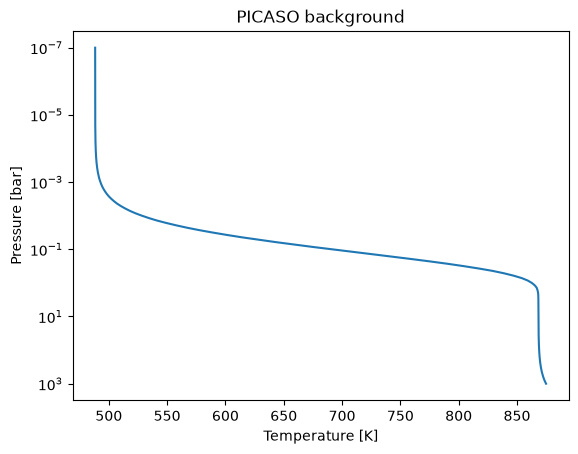

In [ ]:
plt.plot(pt["temperature"], pt["pressure"])
plt.yscale("log")
plt.gca().invert_yaxis()
plt.xlabel("Temperature [K]")
plt.ylabel("Pressure [bar]")
plt.title("PICASO background")
plt.show()

## 7. Choose the vertical mixing profile

$K_{zz}$ controls how efficiently material is mixed vertically.

Caligo can use:

- **one value:** `case.kzz(value=1e8)`
- **a custom array:** `case.kzz(profile=my_kzz)`
- **a smooth three-zone profile:** separate upper, middle, and deep values

The example uses the three-zone option.

In [ ]:
case.kzz(
    upper=1e9,
    mid=1e8,
    deep=1e8,
    break_top_bar=1e-5,
    break_deep_bar=30.0,
    width_dex=0.4,
)

kzz = cb.kzz_profile_from_settings(
    pt["pressure"].values,
    case.kzz_settings,
)

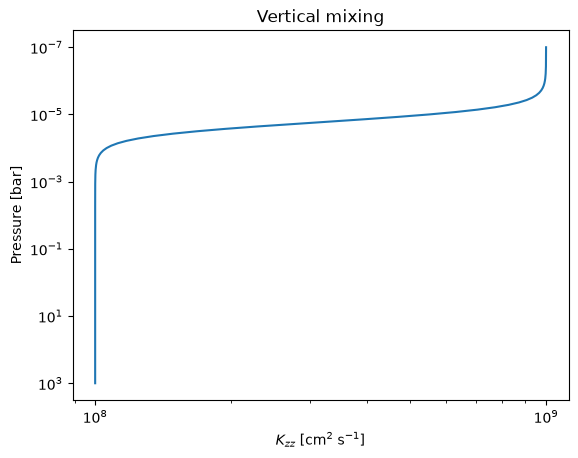

In [ ]:
plt.plot(kzz, pt["pressure"])
plt.xscale("log")
plt.yscale("log")
plt.gca().invert_yaxis()
plt.xlabel(r"$K_{zz}$ [cm$^2$ s$^{-1}$]")
plt.ylabel("Pressure [bar]")
plt.title("Vertical mixing")
plt.show()

## 8. Set up Photochem

Photochem supplies the disequilibrium chemistry and photolysis rates.

The metallicity, C/O ratio, stellar spectrum, reaction network, and $K_{zz}$ profile can all change the chemistry that feeds the haze model.

In [ ]:
case.photochem(
    mechanism_file=str(MECHANISM_FILE),
    thermo_file=str(THERMO_FILE),
    stellar_flux_file=str(STELLAR_FLUX_FILE),
    nz=120,
    P_ref=1e7,
    TOA_pressure=1e-4,
    metallicity=100.0,
    cto_relative=1.0,
    chem_method="photochem+visscher",
)

print("Photochem is configured.")

Photochem is configured.


## 9. Run Photochem

This creates the gas-chemistry background used by Caligo.

The current Gaussian haze-source option still uses this Photochem solution for the atmospheric background and source metadata. Choosing `gaussian` later changes the **shape of haze injection**, not the chemistry step itself.

In [ ]:
start = time.time()

pc, Pbar_pc, z_pc, T_pc = case.run_photochem(
    find_steady_state=True
)

print(f"Photochem finished in {(time.time() - start) / 60:.2f} min")
print("Levels:", len(Pbar_pc))
print("Pressure range:", Pbar_pc.min(), "to", Pbar_pc.max(), "bar")


CALIGO: PHOTOCHEM STEADY STATE
Photochem input P range = [1.000e-07, 1.000e+03] bar
Photochem input T range = [488.3, 874.9] K
Photochem input Kzz range = [1.000e+08, 1.000e+09] cm^2/s
metallicity = 100.0
C/O passed to photochem = 1.0
Running pc.find_steady_state()...
nsteps = 100  longdy = 9.0e-01  max_dT = 1.2e+00  max_dlog10edd = 2.1e-02  TOA_pressure = 1.3e-10
nsteps = 200  longdy = 1.6e+01  max_dT = 1.2e+00  max_dlog10edd = 2.1e-02  TOA_pressure = 1.5e-10
nsteps = 300  longdy = 1.9e+05  max_dT = 1.2e+00  max_dlog10edd = 2.2e-02  TOA_pressure = 2.3e-10
nsteps = 400  longdy = 6.5e+06  max_dT = 1.3e+00  max_dlog10edd = 2.3e-02  TOA_pressure = 2.8e-10
nsteps = 500  longdy = 6.8e+05  max_dT = 1.3e+00  max_dlog10edd = 2.4e-02  TOA_pressure = 3.5e-10
nsteps = 600  longdy = 2.7e+04  max_dT = 1.4e+00  max_dlog10edd = 2.5e-02  TOA_pressure = 4.0e-10
nsteps = 700  longdy = 5.9e+03  max_dT = 1.4e+00  max_dlog10edd = 2.5e-02  TOA_pressure = 4.1e-10
nsteps = 800  longdy = 9.1e+03  max_dT = 1.6

# Part II — Add the haze microphysics

## 10. Choose the Caligo grid and particle bins

The atmospheric grid says where particles are evolved.

The particle grid divides the haze population into size/mass bins. New particles enter one or more of these bins and can move into larger bins through coagulation.

In [ ]:
case.microphysics_grid(
    nz_target=50, #how many layer
    p_top_micro=1e-10, #top of grid in bars
    p_bot_micro=10.0, #bottom of grid in bars
    kzz_micro_scale=1.0, #you can scale the kzz without rerunning photochem
)

case.particles(
    n_bin=40, #how many bin sizes do you want
    rho_haze=1.0, #density 
    r_monomer_nm=1.0, #monomer radius
    bin_mass_ratio=2.0, #ratio of bin masses
)

print("Atmospheric levels:", case.microphysics_grid_settings["nz_target"])
print("Particle bins:", case.particle_settings["n_bin"])

Atmospheric levels: 50
Particle bins: 40


# 11. Choose the haze source

This is one of the main Caligo choices.

### Option A — Photochemical source

```python
SOURCE_VERTICAL_MODE = "photochem"
```

The haze follows the vertical photolysis profile of selected precursor molecules.

### Option B — Gaussian source

```python
SOURCE_VERTICAL_MODE = "gaussian"
```

The haze is placed in a Gaussian-shaped layer with a chosen peak pressure and width.

The Gaussian option is useful for controlled experiments where the source layer should be moved around without changing the chemistry.

In [ ]:
# Choose one:
SOURCE_VERTICAL_MODE = "photochem"
# SOURCE_VERTICAL_MODE = "gaussian"

GAUSS_PEAK_BAR = 1e-7
GAUSS_SIGMA_DEX = 0.50

## 12. Choose the total haze-production rate

There are two useful ways to set the total source strength.

**Fixed flux:** use the same total haze flux in every comparison run.

```python
USE_FIXED_FLUX = True
```

**Photochem-scaled:** use the raw Photochem source multiplied by `SOURCE_FLUX_SCALE`.

```python
USE_FIXED_FLUX = False
```

In [ ]:
USE_FIXED_FLUX = True

TARGET_HAZE_FLUX = 1e-13
SOURCE_FLUX_SCALE = 1.0

HAZE_PARENTS = ["HCN", "C2H2"]
#add something to print possible haze parents

YIELD_HAZE = 0.10

## 13. Choose the size of fresh particles

New haze can enter the particle grid in three ways:

- `single_bin` — all fresh haze starts in one bin
- `lognormal` — fresh haze is spread around a chosen radius
- `custom_weights` — manually choose the fraction entering every bin

The baseline starts everything in the smallest bin and lets coagulation build larger particles.

In [ ]:
SOURCE_BIN_MODE = "single_bin"
# SOURCE_BIN_MODE = "lognormal"
# SOURCE_BIN_MODE = "custom_weights"

SOURCE_BIN_INDEX = 0
SOURCE_R0_NM = 2.0
SOURCE_SIGMA_DEX = 0.20
SOURCE_BIN_WEIGHTS = None

## 14. Attach the source settings

For a Photochem-shaped source, `split_top_flux` keeps the source inside the Caligo grid and treats source above the grid as a downward top-boundary flux.

Other Photochem coupling choices are `in_domain_only` and `renormalize_in_domain`.

In [ ]:
case.haze_source(
    vertical_mode=SOURCE_VERTICAL_MODE,
    coupling_mode="split_top_flux",
    parents=HAZE_PARENTS,
    yield_model="parent_molecular_mass",
    yield_haze=YIELD_HAZE,
    use_fixed_flux=USE_FIXED_FLUX,
    target_haze_flux=TARGET_HAZE_FLUX,
    source_flux_scale=SOURCE_FLUX_SCALE,
    gauss_peak_bar=GAUSS_PEAK_BAR,
    gauss_sigma_dex=GAUSS_SIGMA_DEX,
    bin_mode=SOURCE_BIN_MODE,
    bin_index=SOURCE_BIN_INDEX,
    r0_nm=SOURCE_R0_NM,
    sigma_dex=SOURCE_SIGMA_DEX,
    bin_weights=SOURCE_BIN_WEIGHTS,
)

print("Source mode:", SOURCE_VERTICAL_MODE)

Source mode: photochem


## 15. Build the Photochem source information

Caligo first reads the precursor photolysis rates from Photochem.

If `SOURCE_VERTICAL_MODE="photochem"`, this profile becomes the vertical source shape.

If `SOURCE_VERTICAL_MODE="gaussian"`, Caligo replaces the vertical shape later with the Gaussian selected above.

In [ ]:
source_info = case.build_haze_source()

print("Precursors:", source_info["precursors"])
print("Raw Photochem haze flux:", source_info["F_photochem_raw"])
print("Species contributions:", source_info["species_flux"])


CALIGO: PHOTOCHEM HAZE SOURCE
Photolysis haze precursors: ['C2H2', 'HCN']
Source yield model = parent_molecular_mass
Yield haze = 0.1
Raw haze source flux = 5.849e-13 g cm^-2 s^-1
      C2H2: 1.109e-13 (0.19), haze mass per photolyzed molecule = 4.324e-24 g
       HCN: 4.741e-13 (0.81), haze mass per photolyzed molecule = 4.488e-24 g
Source peak P = 7.069e-09 bar, z = 2.868e+08 cm
Precursors: ['C2H2', 'HCN']
Raw Photochem haze flux: 5.849214150026387e-13
Species contributions: {'C2H2': 1.108632160502064e-13, 'HCN': 4.740581989524323e-13}


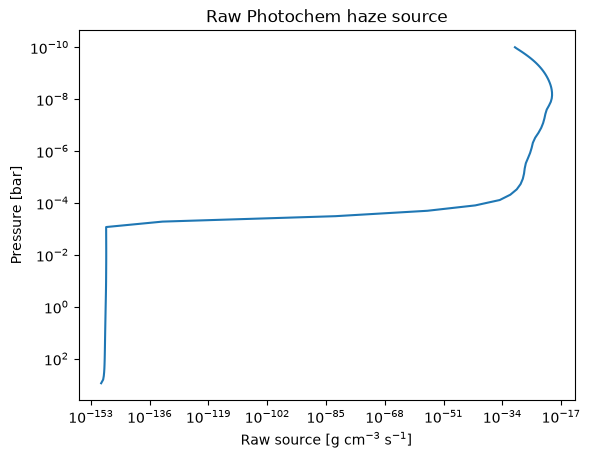

In [ ]:
plt.plot(
    np.maximum(source_info["q_raw"], 1e-300),
    source_info["Pbar_src_sorted"],
)
plt.xscale("log")
plt.yscale("log")
plt.gca().invert_yaxis()
plt.xlabel(r"Raw source [g cm$^{-3}$ s$^{-1}$]")
plt.ylabel("Pressure [bar]")
plt.title("Raw Photochem haze source")
plt.show()

## 16. Compact particles or aggregates?

Set `USE_AGGREGATES=False` for compact spheres.

Set `USE_AGGREGATES=True` to allow porous aggregate geometry. Aggregate structure can affect collision sizes, settling, and optical properties.

In [ ]:
USE_AGGREGATES = True

case.aggregates(
    use=USE_AGGREGATES,
    df_fixed=2.0,
    r_primary_nm=10.0,
    pressure_dependent=True,
    transition_p_bar=1e-6,
    transition_width_dex=0.5,
    use_agg_in_settling=True,
    use_agg_in_coag=True,
)

print("Aggregates:", USE_AGGREGATES)

Aggregates: True


## 17. Choose the coagulation physics

Brownian collisions are the baseline.

Other useful comparisons are:

- coagulation on vs. off
- Brownian only vs. differential settling
- charged vs. neutral particles

In [ ]:
USE_COAGULATION = True
USE_DIFFERENTIAL_SETTLING = False
USE_CHARGE_SUPPRESSION = True

case.coagulation(
    use=USE_COAGULATION,
    brownian=True,
    differential_settling=USE_DIFFERENTIAL_SETTLING,
    charge_suppression=USE_CHARGE_SUPPRESSION,
    charge_density_e_per_um=15.0,
)

print("Coagulation:", USE_COAGULATION)
print("Differential settling collisions:", USE_DIFFERENTIAL_SETTLING)
print("Charge suppression:", USE_CHARGE_SUPPRESSION)

Coagulation: True
Differential settling collisions: False
Charge suppression: True


## 18. Choose transport and removal

Particles can diffuse, settle, and leave through the bottom boundary.

Bottom-boundary choices are:

- `deposition_velocity`
- `open_flux`
- `zero_flux`

Thermal destruction can also be turned off by setting `USE_THERMAL_DESTRUCTION=False`.

In [ ]:
BOTTOM_BC = "deposition_velocity"
USE_THERMAL_DESTRUCTION = True

case.transport(
    settling=True,
    settling_scale=1.0,
    bottom_bc=BOTTOM_BC,
)

case.sinks(
    thermal_model="finite_rate_smooth_T" if USE_THERMAL_DESTRUCTION else "off",
    therm_destroy_t_on_k=650.0,
    therm_destroy_width_k=100.0,
    therm_destroy_timescale=1e5,
    use_deep_recycling=False,
)

print("Bottom boundary:", BOTTOM_BC)
print("Thermal destruction:", USE_THERMAL_DESTRUCTION)

Bottom boundary: deposition_velocity
Thermal destruction: True


## 19. Choose a test run or a production run

A short test is useful for checking that the model starts correctly.

A production run gives the solver much more time to approach steady state.

In [ ]:
RUN_MODE = "production"
# RUN_MODE = "test"

if RUN_MODE == "test":
    case.solver(
        chunk_time=1e4,
        max_chunks=2,
    )
else:
    case.solver(
        dt_init=1e2,
        dt_growth=1.03,
        dt_max=300.0,
        chunk_time=1e5,
        max_chunks=200,
        ss_tol_storage=0.08,
        ss_tol_balance=0.25,
        ss_tol_profile=0.04,
        ss_tol_peak_dex=0.25,
        ss_min_stable_chunks=3,
    )

print("Run mode:", RUN_MODE)

Run mode: production


## 20. Build the microphysics context

This is the best place to check the setup before starting the expensive solver.

The final injected source shown here is the source Caligo will actually use. This makes it easy to see the difference between `photochem` and `gaussian`.

In [ ]:
ctx = case.prepare_microphysics(
    with_coagulation=USE_COAGULATION
)

source_peak_index = np.argmax(ctx["S_mass_density"])

print("Pressure range:", ctx["Pbar"].min(), "to", ctx["Pbar"].max(), "bar")
print("Particle bins:", ctx["n_bin"])
print("Final haze flux:", ctx["F_src"], "g cm^-2 s^-1")
print("Source peak:", ctx["Pbar"][source_peak_index], "bar")


CALIGO: MICROPHYSICS CONTEXT
Mean molecular weight computed from photochem: mu range = [1.139, 4.672], using 92 gas species.
Microphysics grid nz = 50
Microphysics P range = [7.641e+00, 1.000e-10] bar
Microphysics T range = [488.3, 868.4] K
Bottom P/T = 7.641e+00 bar / 868.4 K
Top P/T    = 1.000e-10 bar / 488.3 K
Raw total photochem source = 5.849e-13 g cm^-2 s^-1
Raw in-domain source       = 5.849e-13 g cm^-2 s^-1
Raw above-domain source    = 0.000e+00 g cm^-2 s^-1
Raw below-domain source    = 5.813e-142 g cm^-2 s^-1
Source scale factor        = 1.710e-01
Final volumetric source    = 1.000e-13 g cm^-2 s^-1
Final top-boundary source  = 0.000e+00 g cm^-2 s^-1
Final total source         = 1.000e-13 g cm^-2 s^-1
Source peak pressure       = 5.984e-09 bar
parameterized thermal destruction active: T_on=650.0 K, width=100.0 K, tau=1.000e+05 s
Max thermal destruction rate = 9.875e-06 s^-1
Max settling speed = 6.578e+08 cm/s
Min positive settling speed = 6.923e-07 cm/s
Mixing time range = [6.

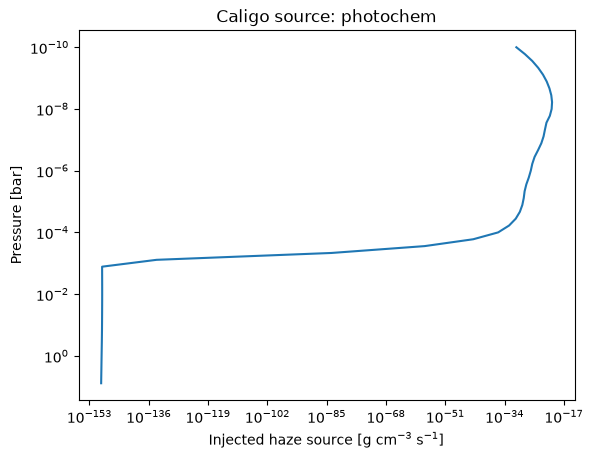

In [ ]:
plt.plot(
    np.maximum(ctx["S_mass_density"], 1e-300),
    ctx["Pbar"],
)
plt.xscale("log")
plt.yscale("log")
plt.gca().invert_yaxis()
plt.xlabel(r"Injected haze source [g cm$^{-3}$ s$^{-1}$]")
plt.ylabel("Pressure [bar]")
plt.title(f"Caligo source: {SOURCE_VERTICAL_MODE}")
plt.show()

# Part III — Run Caligo

## 21. Run the haze microphysics

This evolves the particle distribution through source injection, coagulation, vertical transport, settling, and the selected sinks.

Production runs can take a while. The result is saved in one dictionary called `result`.

In [ ]:
start = time.time()

result = case.run_microphysics(
    prepare_context=False,
    with_coagulation=USE_COAGULATION,
    verbose=True,
)

print(f"Finished in {(time.time() - start) / 60:.2f} min")
print("Converged:", result["converged"])
print("Column mass:", result["column_mass"], "g cm^-2")
print("Peak haze pressure:", result["peak_pressure"], "bar")


CALIGO: FULL MICROPHYSICS INTEGRATION
dt_init = 1.000e+02 s
dt_growth = 1.030e+00
dt_max = 3.000e+02 s
chunk_time = 1.000e+05 s
max_chunks = 200
max_column_jump_frac = 1.000e+00

--- Chunk 1/200 ---
t = 1.000e+05 s (1.157e+00 d)
steps in chunk = 350
column mass = 9.812e-09 g cm^-2
F_source = 1.000e-13 g cm^-2 s^-1
F_sink = 1.877e-15 g cm^-2 s^-1
F_bottom = 1.749e-60 g cm^-2 s^-1
F_thermal = 1.877e-15 g cm^-2 s^-1
F_deep = 0.000e+00 g cm^-2 s^-1
F_storage = 9.812e-14 g cm^-2 s^-1
storage_ratio = 9.812e-01
balance_ratio = 9.812e-01
profile_change = 1.000e+00
peak_pressure = 2.775e-08 bar
peak_shift_dex = 2.887e+00
max_sed_substeps = 9
coag_substeps total = 638
max_coag_substeps = 3
coag_active_layers = 17
max_coag_max_dtl = 8.111e-02
stable_chunks = 0

--- Chunk 2/200 ---
t = 2.000e+05 s (2.315e+00 d)
steps in chunk = 335
column mass = 1.926e-08 g cm^-2
F_source = 1.000e-13 g cm^-2 s^-1
F_sink = 5.526e-15 g cm^-2 s^-1
F_bottom = 1.117e-52 g cm^-2 s^-1
F_thermal = 5.526e-15 g cm^-2 s^-1


## 22. Read the result

`case.summary()` gives the main physical and numerical information without needing to dig through the result dictionary manually.

In [ ]:
case.summary(result)

The convergence history can also be viewed as a normal pandas table.

In [ ]:
history = diag.history_table(result=result)

show_columns = [
    "chunk",
    "t_end",
    "column_mass",
    "F_source",
    "F_sink",
    "F_storage",
    "storage_ratio",
    "balance_ratio",
    "profile_change",
    "peak_pressure",
]

show_columns = [
    col for col in show_columns
    if col in history.columns
]

display(history[show_columns].tail(10))

## 23. Plot the standard Caligo diagnostics

Caligo already includes a basic plotting helper for the P-T profile, $K_{zz}$, haze profile, particle-size distribution, column history, and flux history.

In [ ]:
case.plot(result)

## 24. Save the run

The long microphysics calculation is the expensive part, so saving it makes later plotting and comparison much easier.

In [ ]:
RUN_LABEL = f"gj1214b_{SOURCE_VERTICAL_MODE}"
output_dir = PROJECT_ROOT / "outputs" / RUN_LABEL
output_dir.mkdir(parents=True, exist_ok=True)

diag.save_result_npz(
    result,
    output_dir / f"{RUN_LABEL}_result.npz",
)

diag.save_history_csv(
    result=result,
    filename=output_dir / f"{RUN_LABEL}_history.csv",
)

diag.save_summary_txt(
    case,
    result=result,
    filename=output_dir / f"{RUN_LABEL}_summary.txt",
)

print("Saved to:", output_dir)

# Part IV — Optional optical properties

Caligo's microphysics result can be turned into PICASO-ready haze optical properties using a refractive-index file.

Two current choices are:

- `compact_mie` — treat particles as compact spheres
- `aggregate_effective_mie` — use Caligo's porous aggregate geometry with an effective-medium Mie approximation

This step does **not** rerun the microphysics.

In [ ]:
# Replace this with the refractive-index file being tested.
REFRIND_FILE = Path(
    "/path/to/material.refrind"
)

OPTICS_MODE = "aggregate_effective_mie"
# OPTICS_MODE = "compact_mie"

print("Optics mode:", OPTICS_MODE)
print("Refractive-index file exists:", REFRIND_FILE.exists())

If a refractive-index file has been selected, this builds the PICASO cloud table.

In [ ]:
if REFRIND_FILE.exists():

    cloud_df, optics_out = copt.build_picaso_cloud_from_caligo(
        result=result,
        case=case,
        refractive_index_file=REFRIND_FILE,
        optics_mode=OPTICS_MODE,
        n_wavelength=180,
        attach_photochem_atmosphere=True,
        use_virga_format=False,
        verbose=True,
    )

    print("Cloud table rows:", len(cloud_df))

else:
    print("Set REFRIND_FILE before running the optics section.")

A clear and hazy transmission spectrum can then be calculated with PICASO.

In [ ]:
if REFRIND_FILE.exists():

    spectra = copt.run_clear_and_hazy_transmission(
        case=case,
        opacity_ck=opacity_ck,
        cloud_df=cloud_df,
    )

    plt.plot(
        spectra["wavelength_clear_um"],
        spectra["transit_depth_clear_ppm"],
        label="clear",
    )

    plt.plot(
        spectra["wavelength_hazy_um"],
        spectra["transit_depth_hazy_ppm"],
        label="hazy",
    )

    plt.xlabel("Wavelength [micron]")
    plt.ylabel("Transit depth [ppm]")
    plt.legend()
    plt.show()

# 25. Easy comparison runs to try next

Once one baseline works, useful experiments are easy to make by changing one choice at a time.

### Haze source

```python
SOURCE_VERTICAL_MODE = "photochem"
SOURCE_VERTICAL_MODE = "gaussian"
```

### Source strength

```python
USE_FIXED_FLUX = True
USE_FIXED_FLUX = False
```

### Fresh particles

```python
SOURCE_BIN_MODE = "single_bin"
SOURCE_BIN_MODE = "lognormal"
SOURCE_BIN_MODE = "custom_weights"
```

### Particle structure

```python
USE_AGGREGATES = True
USE_AGGREGATES = False
```

### Coagulation

```python
USE_COAGULATION = True
USE_COAGULATION = False
```

### Charge

```python
USE_CHARGE_SUPPRESSION = True
USE_CHARGE_SUPPRESSION = False
```

### Bottom boundary

```python
BOTTOM_BC = "deposition_velocity"
BOTTOM_BC = "open_flux"
BOTTOM_BC = "zero_flux"
```

### Optical treatment

```python
OPTICS_MODE = "compact_mie"
OPTICS_MODE = "aggregate_effective_mie"
```

The cleanest comparison is usually to change **one setting at a time**, give the run a new label, and compare the saved outputs.

## What Caligo adds to the pipeline

PICASO supplies the atmospheric and radiative-transfer framework.

Photochem supplies the disequilibrium chemistry and photolysis information.

VIRGA supplies settling tools used inside the particle treatment.

Caligo connects those pieces to a sectional haze-microphysics model that follows:

- haze production,
- particle-size bins,
- coagulation,
- aggregate structure,
- diffusion and settling,
- lower-boundary loss,
- thermal destruction,
- convergence and mass-budget diagnostics,
- and optional haze optical properties for PICASO.

The notebook is intentionally modular so the same atmospheric background can be reused while individual microphysics assumptions are changed.